In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import torch

from torch_geometric.data import Data

In [ ]:
features = pd.read_csv("../data/raw/elliptic_txs_features.csv", header=None)
classes = pd.read_csv("../data/raw/elliptic_txs_classes.csv")
edges = pd.read_csv("../data/raw/elliptic_txs_edgelist.csv")


print("Features:", features.shape)
print("Classes:", classes.shape)
print("Edges:", edges.shape)

Features: (203769, 167)
Classes: (203769, 2)
Edges: (234355, 2)


In [4]:
features.columns = ["txId"] + [f"feature_{i}" for i in range(1, features.shape[1])]

features.head()

,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [5]:
data = features.merge(classes, on="txId")

print(data.shape)

data.head()

(203769, 168)


,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [6]:
label_map = {"unknown": -1, "1": 1, "2": 0}

data["class"] = data["class"].astype(str).map(label_map)

data["class"].value_counts()

class
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64

In [7]:
G = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2"
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 203769
Number of edges: 234355


In [8]:
node_mapping = {node: i for i, node in enumerate(G.nodes())}

In [9]:
edge_index = torch.tensor(
    [[node_mapping[src], node_mapping[dst]] for src, dst in G.edges()],
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 234355])


In [10]:
data_sorted = data.set_index("txId").loc[list(G.nodes())]

X = torch.tensor(
    data_sorted.drop(columns=["class"]).values,
    dtype=torch.float
)

print(X.shape)

torch.Size([203769, 166])


In [11]:
y = torch.tensor(
    data_sorted["class"].values,
    dtype=torch.long
)

print(y.shape)

torch.Size([203769])


In [12]:
graph_data = Data(
    x=X,
    edge_index=edge_index,
    y=y
)

print(graph_data)

Data(x=[203769, 166], edge_index=[2, 234355], y=[203769])


In [13]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

In [14]:
import torch.nn as nn

class GCN(nn.Module):

    def __init__(self, num_features, hidden_channels):
        super(GCN, self).__init__()

        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 2)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x

In [15]:
model = GCN(num_features=166, hidden_channels=32)

print(model)

GCN(
  (conv1): GCNConv(166, 32)
  (conv2): GCNConv(32, 2)
)


In [16]:
train_mask = graph_data.y >= 0

print(train_mask.sum())

tensor(46564)


In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [18]:
for epoch in range(50):

    model.train()
    optimizer.zero_grad()

    out = model(graph_data.x, graph_data.edge_index)

    loss = criterion(out[train_mask], graph_data.y[train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.5733636021614075
Epoch 10, Loss: 0.24585728347301483
Epoch 20, Loss: 0.2009754329919815
Epoch 30, Loss: 0.17782379686832428
Epoch 40, Loss: 0.16189159452915192


In [19]:
model.eval()

out = model(graph_data.x, graph_data.edge_index)

pred = out.argmax(dim=1)

correct = (pred[train_mask] == graph_data.y[train_mask]).sum()

accuracy = int(correct) / int(train_mask.sum())

print("Accuracy:", accuracy)

Accuracy: 0.9464607851559145


In [20]:
illicit_predictions = (pred == 1).sum()

print("Predicted suspicious transactions:", illicit_predictions.item())

Predicted suspicious transactions: 12947


In [21]:
from torch_geometric.nn import GATConv

In [22]:
import torch.nn as nn

class GAT(nn.Module):

    def __init__(self, num_features, hidden_channels):

        super(GAT, self).__init__()

        self.gat1 = GATConv(num_features, hidden_channels, heads=4)
        self.gat2 = GATConv(hidden_channels * 4, 2, heads=1)

    def forward(self, x, edge_index):

        x = self.gat1(x, edge_index)
        x = F.relu(x)

        x = self.gat2(x, edge_index)

        return x

In [23]:
gat_model = GAT(num_features=166, hidden_channels=32)

print(gat_model)

GAT(
  (gat1): GATConv(166, 32, heads=4)
  (gat2): GATConv(128, 2, heads=1)
)


In [24]:
gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [25]:
gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [26]:
for epoch in range(50):

    gat_model.train()
    gat_optimizer.zero_grad()

    out = gat_model(graph_data.x, graph_data.edge_index)

    loss = criterion(out[train_mask], graph_data.y[train_mask])

    loss.backward()
    gat_optimizer.step()

    if epoch % 10 == 0:
        print(f"GAT Epoch {epoch}, Loss: {loss.item()}")

GAT Epoch 0, Loss: 0.9685225486755371
GAT Epoch 10, Loss: 0.3145463764667511
GAT Epoch 20, Loss: 0.2001064121723175
GAT Epoch 30, Loss: 0.16424891352653503
GAT Epoch 40, Loss: 0.14326635003089905


In [27]:
gat_model.eval()

out = gat_model(graph_data.x, graph_data.edge_index)

pred = out.argmax(dim=1)

correct = (pred[train_mask] == graph_data.y[train_mask]).sum()

accuracy = int(correct) / int(train_mask.sum())

print("GAT Accuracy:", accuracy)

GAT Accuracy: 0.9566617988145348


In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

In [29]:
# GCN predictions (your current trained model)

model.eval()

gcn_out = model(graph_data.x, graph_data.edge_index)
gcn_pred = gcn_out.argmax(dim=1)

# GAT predictions

gat_model.eval()

gat_out = gat_model(graph_data.x, graph_data.edge_index)
gat_pred = gat_out.argmax(dim=1)

# True labels
y_true = graph_data.y

In [30]:
valid_mask = graph_data.y >= 0

y_true = graph_data.y[valid_mask]

gcn_pred_valid = gcn_pred[valid_mask]
gat_pred_valid = gat_pred[valid_mask]

from sklearn.metrics import accuracy_score

gcn_accuracy = accuracy_score(y_true, gcn_pred_valid)
gat_accuracy = accuracy_score(y_true, gat_pred_valid)

print("GCN Accuracy:", gcn_accuracy)
print("GAT Accuracy:", gat_accuracy)

GCN Accuracy: 0.9464607851559145
GAT Accuracy: 0.9566617988145348


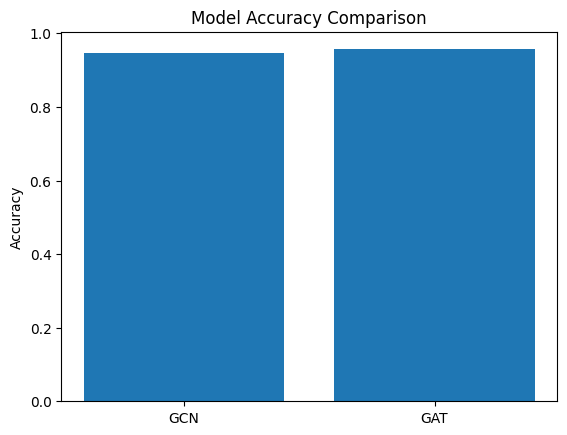

In [31]:
models = ['GCN', 'GAT']
accuracies = [gcn_accuracy, gat_accuracy]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

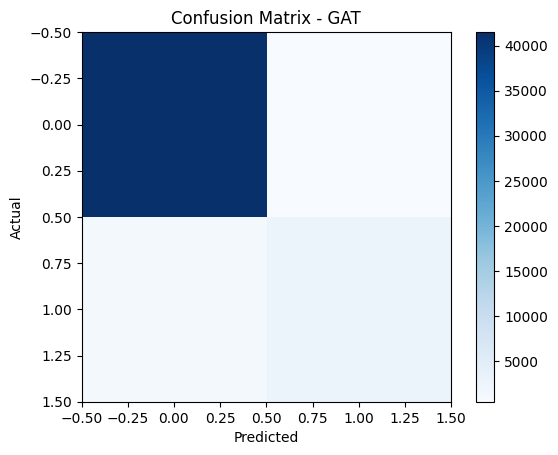

In [32]:
valid_mask = graph_data.y >= 0

y_true = graph_data.y[valid_mask]
gat_pred_valid = gat_pred[valid_mask]

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, gat_pred_valid)

import matplotlib.pyplot as plt

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - GAT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

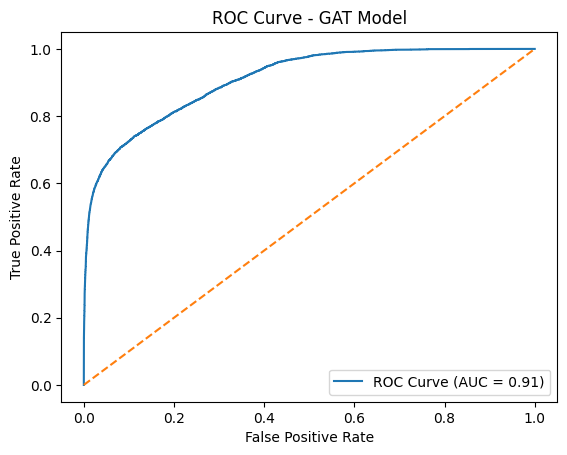

In [33]:
from sklearn.metrics import roc_curve, auc

valid_mask = graph_data.y >= 0

y_true = graph_data.y[valid_mask]

# probability of fraud class
probs = gat_out[:,1].detach().numpy()

probs_valid = probs[valid_mask]

fpr, tpr, _ = roc_curve(y_true, probs_valid)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GAT Model")
plt.legend()
plt.show()

In [34]:
with torch.no_grad():

    embeddings = gat_model.gat1(graph_data.x, graph_data.edge_index)

    embeddings = embeddings.detach().numpy()

print("Embedding Shape:", embeddings.shape)

Embedding Shape: (203769, 128)


In [35]:
from sklearn.ensemble import IsolationForest

In [36]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

iso_forest.fit(embeddings)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [37]:
anomaly_scores = iso_forest.decision_function(embeddings)

print("Anomaly Scores Shape:", anomaly_scores.shape)

Anomaly Scores Shape: (203769,)


In [38]:
anomaly_labels = iso_forest.predict(embeddings)

# convert to fraud indicator
suspicious_transactions = (anomaly_labels == -1).sum()

print("Detected Suspicious Transactions:", suspicious_transactions)

Detected Suspicious Transactions: 4076


In [39]:
import torch.nn.functional as F

gnn_probs = F.softmax(gat_out, dim=1)

fraud_prob = gnn_probs[:,1].detach().numpy()

print("Fraud probability shape:", fraud_prob.shape)

Fraud probability shape: (203769,)


In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

anomaly_scores_scaled = scaler.fit_transform(
    anomaly_scores.reshape(-1,1)
).flatten()

print("Scaled anomaly scores shape:", anomaly_scores_scaled.shape)

Scaled anomaly scores shape: (203769,)


In [41]:
risk_scores = (
    0.7 * fraud_prob +
    0.3 * (1 - anomaly_scores_scaled)
)

print("Risk scores shape:", risk_scores.shape)

Risk scores shape: (203769,)


In [42]:
import numpy as np

risk_levels = np.where(
    risk_scores > 0.65, "High Risk",
    np.where(
        risk_scores > 0.45, "Medium Risk",
        "Low Risk"
    )
)

unique, counts = np.unique(risk_levels, return_counts=True)

print(dict(zip(unique, counts)))

{np.str_('High Risk'): np.int64(1309), np.str_('Low Risk'): np.int64(195883), np.str_('Medium Risk'): np.int64(6577)}


In [43]:
top_risk_idx = np.argsort(risk_scores)[-10:]

print("Top High Risk Transactions:")

for idx in top_risk_idx:
    print(
        "Node:", idx,
        "Risk Score:", round(risk_scores[idx],3)
    )

Top High Risk Transactions:
Node: 173539 Risk Score: 0.882
Node: 169228 Risk Score: 0.882
Node: 171766 Risk Score: 0.882
Node: 173258 Risk Score: 0.882
Node: 173626 Risk Score: 0.883
Node: 167475 Risk Score: 0.883
Node: 173411 Risk Score: 0.884
Node: 170529 Risk Score: 0.884
Node: 169674 Risk Score: 0.885
Node: 167264 Risk Score: 0.893


In [44]:
import networkx as nx
import community as community_louvain

In [45]:
G = nx.Graph()

edges_list = edge_index.t().tolist()

G.add_edges_from(edges_list)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 203769
Number of edges: 234355


In [46]:
partition = community_louvain.best_partition(G)

print("Total Communities Detected:", len(set(partition.values())))

Total Communities Detected: 306


In [ ]:
import numpy as np

community_labels = np.array([partition[i] for i in range(len(partition))])

print("Community labels shape:", community_labels.shape)

Community labels shape: (203769,)


In [ ]:
community_risk = {}

for node in range(len(community_labels)):

    community = community_labels[node]

    if community not in community_risk:
        community_risk[community] = 0

    if risk_levels[node] == "High Risk":
        community_risk[community] += 1

suspicious_communities = {
    c:r for c,r in community_risk.items() if r > 5
}

print("Suspicious Communities:", len(suspicious_communities))

Suspicious Communities: 11


In [ ]:
sorted_communities = sorted(
    suspicious_communities.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Top Suspicious Communities:")

for c,r in sorted_communities[:5]:
    print("Community:", c, "High Risk Nodes:", r)

Top Suspicious Communities:
Community: 101 High Risk Nodes: 79
Community: 206 High Risk Nodes: 77
Community: 186 High Risk Nodes: 69
Community: 188 High Risk Nodes: 68
Community: 270 High Risk Nodes: 62


In [ ]:
high_risk_nodes = np.where(risk_levels == "High Risk")[0]

print("Total High Risk Nodes:", len(high_risk_nodes))

Total High Risk Nodes: 549


In [ ]:
suspicious_paths = []

for i in range(min(50, len(high_risk_nodes))):  # limit to first 50 nodes
    start = high_risk_nodes[i]
    
    for j in range(i+1, min(50, len(high_risk_nodes))):
        end = high_risk_nodes[j]
        
        try:
            path = nx.shortest_path(G, source=start, target=end)
            
            if len(path) <= 6:  # limit chain length
                suspicious_paths.append(path)
                
        except nx.NetworkXNoPath:
            continue

print("Detected Suspicious Chains:", len(suspicious_paths))

Detected Suspicious Chains: 285


In [ ]:
print("Example Suspicious Chains:\n")

for chain in suspicious_paths[:5]:
    print(chain)

Example Suspicious Chains:

[np.int64(46852), 47180]
[np.int64(46852), 47204]
[np.int64(46852), 47880]
[np.int64(46852), 47939]
[np.int64(46852), 47939, np.int64(48320)]


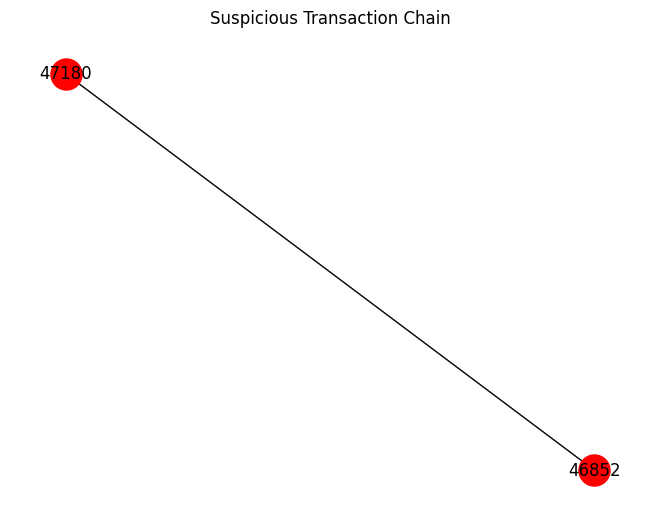

In [ ]:
chain = suspicious_paths[0]

subG = G.subgraph(chain)

pos = nx.spring_layout(subG)

nx.draw(
    subG,
    pos,
    with_labels=True,
    node_color="red",
    node_size=500
)

plt.title("Suspicious Transaction Chain")
plt.show()

In [ ]:
# Select nodes to visualize
high_nodes = np.where(risk_levels == "High Risk")[0][:30]
medium_nodes = np.where(risk_levels == "Medium Risk")[0][:30]

selected_nodes = list(high_nodes) + list(medium_nodes)

subG = G.subgraph(selected_nodes)

print("Nodes in visualization:", subG.number_of_nodes())

Nodes in visualization: 60


In [ ]:
node_colors = []

for node in subG.nodes():

    if risk_levels[node] == "High Risk":
        node_colors.append("red")

    elif risk_levels[node] == "Medium Risk":
        node_colors.append("yellow")

    else:
        node_colors.append("green")

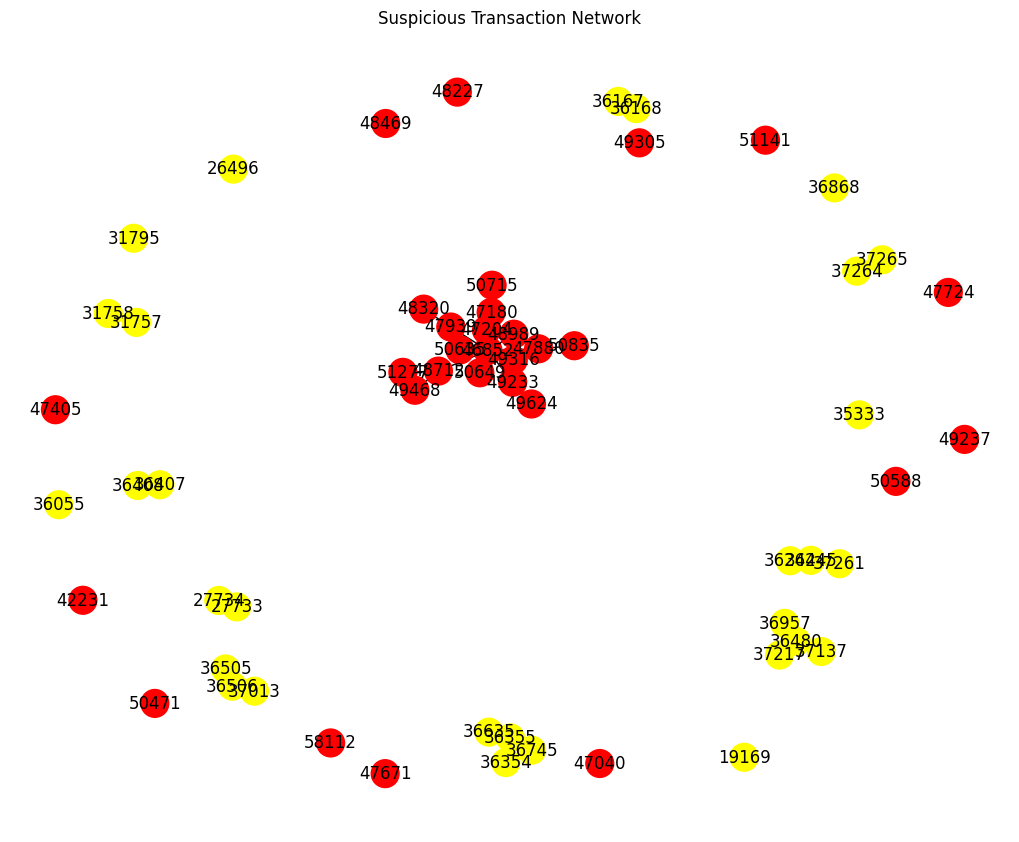

In [ ]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(subG)

nx.draw(
    subG,
    pos,
    node_color=node_colors,
    with_labels=True,
    node_size=400
)

plt.title("Suspicious Transaction Network")
plt.show()

In [ ]:
from src.models.gcn_model import GCN, train_gcn, predict_gcn

gcn_model = GCN(num_features=166, hidden_channels=32)

gcn_model = train_gcn(gcn_model, graph_data, train_mask)

gcn_pred, gcn_out = predict_gcn(gcn_model, graph_data)

print("GCN predictions shape:", gcn_pred.shape)

Epoch 0, Loss: 1.6347837448120117
Epoch 10, Loss: 0.3517151474952698
Epoch 20, Loss: 0.254646897315979
Epoch 30, Loss: 0.2064405232667923
Epoch 40, Loss: 0.18563838303089142
GCN predictions shape: torch.Size([203769])


In [ ]:
from src.models.gat_model import GAT, train_gat, predict_gat

gat_model = GAT(num_features=166, hidden_channels=32)

gat_model = train_gat(gat_model, graph_data, train_mask)

gat_pred, gat_out = predict_gat(gat_model, graph_data)

print("GAT predictions shape:", gat_pred.shape)

ModuleNotFoundError: No module named 'src'